# 🟤 Copper Spot Price Forecasting — 1-Day Horizon

**1-day-ahead forecast: run today to get tomorrow's copper price prediction**

This notebook is a variant of `copper_forecast.ipynb` configured for next-day forecasting.
It trains all models, selects the best by out-of-sample Sharpe ratio, and prints
a forecast for the next trading day with an 80% confidence interval.

All other sections (data ingestion, feature engineering, model zoo, CV, backtesting,
SHAP explainability, scenario analysis) are identical to the main notebook.


## 1. Setup & Configuration


In [1]:
import os
import sys
import warnings
import logging
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

from src.data_ingestion import load_data
from src.feature_engineering import build_features, split_features_targets
from src.models import NaiveModel, LinearModel, XGBoostModel, LGBMModel, EnsembleModel, QuantileForecaster
from src.models_arimax import ARIMAXModel
from src.models_hybrid import HybridModel
from src.models_stacking import StackingEnsemble
from src.evaluation import compute_metrics, walk_forward_cv, compare_models, out_of_sample_backtest
from src.visualization import (
    plot_price_history, plot_feature_correlations, plot_cv_results,
    plot_forecast_with_ci, plot_model_comparison, plot_shap_summary,
    plot_scenario_tornado, plot_dashboard, plot_regime_overlay,
)
from src.scenario_analysis import ScenarioEngine, SCENARIO_TEMPLATES
from src.cointegration import add_cointegration_features
from src.regime_detection import RegimeDetector
from src.feature_pruning import auto_prune_features

# Prophet is optional (heavy dependency)
try:
    from src.models_prophet import ProphetModel
    HAS_PROPHET = True
    print('✅ Prophet available')
except ImportError:
    HAS_PROPHET = False
    print('⚠️  Prophet not installed — ProphetModel will be skipped')

print('✅ All imports OK')

✅ Prophet available
✅ All imports OK


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────────────────
CFG = {
    'start_date':        '2010-01-01',
    'forecast_horizon':  1,               # 1-day ahead (next trading day)
    'all_horizons':      [1, 5, 22, 66],  # still engineer multi-horizon features
    'lags':              [1, 5, 22],      # look-back periods
    'initial_train_size': 504,            # ~2 years
    'cv_step_size':       5,              # re-fit weekly (finer than monthly for daily pred)
    'holdout_size':       252,            # ~1 year OOS backtest
    'ci_alpha':           0.80,           # confidence interval width
    'optuna_trials':      30,             # reduced for speed (set to 0 to skip)
    'fred_api_key':       os.environ.get('FRED_API_KEY', None),
    'nasdaq_api_key':     os.environ.get('NASDAQ_DATA_LINK_API_KEY', None),
    'random_seed':        42,
    'output_dir':         './outputs_1d',
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Configuration:', CFG)


Configuration: {'start_date': '2010-01-01', 'forecast_horizon': 1, 'all_horizons': [1, 5, 22, 66], 'lags': [1, 5, 22], 'initial_train_size': 504, 'cv_step_size': 5, 'holdout_size': 252, 'ci_alpha': 0.8, 'optuna_trials': 30, 'fred_api_key': None, 'nasdaq_api_key': None, 'random_seed': 42, 'output_dir': './outputs_1d'}


## 2. Data Ingestion

Data is downloaded from three sources:
- **yfinance**: Copper (HG=F), DXY, Gold, Aluminium, Oil, CNY/USD, S&P 500, Shanghai
- **FRED API**: Industrial production, real yields, inflation breakeven, M2
- **CFTC COT**: Commercial/non-commercial positioning, open interest, speculative ratio

If no API keys are available, synthetic placeholder series are used (safe for testing).

In [3]:
df_raw = load_data(
    start=CFG['start_date'],
    fred_api_key=CFG['fred_api_key'],
    include_cot=True,
    nasdaq_api_key=CFG['nasdaq_api_key'],
)
print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'\nColumns: {list(df_raw.columns)}')
df_raw.tail()

INFO | yfinance: downloaded 4237 rows for 8 tickers
WARNING | No FRED API key supplied or fredapi unavailable. Generating synthetic placeholder series.
WARNING | COT: No API key or fetch failed. Generating synthetic COT data.
INFO | COT data integrated: 4 columns added
INFO | Combined dataset: 4237 rows × 17 columns


Dataset shape: (4237, 17)
Date range: 2010-01-04 → 2026-04-02

Columns: ['shanghai', 'aluminium', 'oil', 'cny_usd', 'dxy', 'gold', 'copper_price', 'sp500', 'indpro', 'real_yield_10y', 'inflation_breakeven', 'ism_pmi', 'us_m2', 'commercial_net', 'noncommercial_net', 'open_interest', 'spec_ratio']


,shanghai,aluminium,oil,cny_usd,dxy,gold,copper_price,sp500,indpro,real_yield_10y,inflation_breakeven,ism_pmi,us_m2,commercial_net,noncommercial_net,open_interest,spec_ratio
Date,,,,,,,,,,,,,,,,,
2026-03-27,3913.724121,3187.50,99.639999,0.144703,100.150002,4492.000000,12052.657557,6368.850098,59.938525,0.876197,207.521348,294.977342,196.627861,8084.115189,824.054213,142009.876727,0.349905
2026-03-30,3923.287109,3336.25,102.879997,0.144684,100.510002,4526.000000,12072.498750,6343.720215,59.531251,0.519574,205.313153,295.048603,196.608160,8084.115189,824.054213,142009.876727,0.349905
2026-03-31,3891.861084,3405.50,101.379997,0.144684,99.959999,4647.600098,12318.314460,6528.520020,59.511157,0.981332,203.261863,294.123749,197.141572,8084.115189,824.054213,142009.876727,0.349905
2026-04-01,3948.552002,3452.25,100.120003,0.145049,99.650002,4783.200195,12398.783040,6575.319824,57.926940,0.604842,202.716295,294.381528,197.505959,8084.115189,824.054213,142009.876727,0.349905
2026-04-02,3919.284912,3411.00,111.540001,0.145550,100.029999,4651.500000,12264.301506,6582.689941,56.765630,2.252393,203.821145,294.155830,199.386409,8084.115189,824.054213,142009.876727,0.349905


In [4]:
# Summary statistics
df_raw.describe().round(2)


,shanghai,aluminium,oil,cny_usd,dxy,gold,copper_price,sp500,indpro,real_yield_10y,inflation_breakeven,ism_pmi,us_m2,commercial_net,noncommercial_net,open_interest,spec_ratio
count,4230.00,3082.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00
mean,2993.90,2218.11,71.56,0.15,92.83,1712.44,7604.12,3005.56,35.04,66.64,101.12,203.00,184.90,11483.28,3634.60,159891.20,0.25
std,520.35,398.84,20.72,0.01,9.32,701.46,1797.57,1554.67,31.81,36.94,37.21,56.69,45.60,5314.70,4095.47,17939.04,0.14
min,1950.01,1452.00,-37.63,0.14,72.93,1050.80,4275.86,1022.58,-19.31,-12.91,41.99,92.23,92.94,-3951.07,-6289.78,127022.06,-0.00
25%,2670.09,1910.88,54.76,0.14,82.64,1271.40,6161.91,1831.98,11.71,30.73,77.09,142.10,145.89,8452.30,527.28,145955.19,0.12
50%,3049.15,2239.50,71.47,0.15,95.30,1523.20,7386.58,2634.56,28.74,76.66,96.03,226.82,193.24,12255.40,3786.52,158639.95,0.25
75%,3306.42,2428.00,88.20,0.16,99.22,1843.10,8927.61,4132.15,62.48,96.31,106.25,240.81,219.33,15469.77,7190.69,173716.63,0.38
max,5166.35,3873.00,123.70,0.17,114.11,5318.40,13614.63,6978.60,104.56,130.38,221.27,295.05,258.34,21972.03,11896.87,203183.74,0.49


In [5]:
# Missing data audit
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing data audit:')
print(audit[audit['missing_count'] > 0].to_string() if (audit['missing_count'] > 0).any() else 'No missing data')


Missing data audit:
           missing_count  missing_pct
shanghai               7          0.2
aluminium           1155         27.3


## 3. Exploratory Data Analysis

### 3.1 Copper price history


In [6]:
fig_price = plot_price_history(df_raw)
fig_price.show()


### 3.2 Correlation with copper price


In [7]:
# Pairwise correlations of all series with copper price
corr_all = df_raw.corr()['copper_price'].drop('copper_price').sort_values()
import plotly.express as px
fig_corr_bar = px.bar(
    x=corr_all.values, y=corr_all.index,
    orientation='h', title='Pearson Correlation with Copper Price',
    labels={'x': 'Pearson r', 'y': 'Series'},
    template='plotly_white',
    color=corr_all.values,
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
)
fig_corr_bar.show()


### 3.3 Return distribution


In [8]:
log_ret = np.log(df_raw['copper_price'] / df_raw['copper_price'].shift(1)).dropna()

import plotly.graph_objects as go
fig_dist = go.Figure()
fig_dist.add_trace(go.Histogram(
    x=log_ret, nbinsx=80, name='Daily log return',
    marker_color='#b87333', opacity=0.75,
))
fig_dist.update_layout(
    title='Distribution of Daily Copper Log Returns',
    xaxis_title='Log Return', yaxis_title='Count',
    template='plotly_white',
)
fig_dist.show()
print(f'Skewness: {log_ret.skew():.3f}  |  Kurtosis: {log_ret.kurt():.3f}')
print(f'Ann. volatility: {log_ret.std() * np.sqrt(252):.1%}')


Skewness: -1.121  |  Kurtosis: 21.583
Ann. volatility: 23.8%


## 4. Cointegration Analysis & Regime Detection

### 4.1 Cointegration tests

We test copper's long-run equilibrium relationships with gold, aluminium, oil, DXY, and CNY using the Engle-Granger two-step procedure. For cointegrated pairs, rolling error-correction terms (ECTs) are computed as features.

In [9]:
# Run cointegration tests and add ECT features
df_aug, coint_results = add_cointegration_features(df_raw)

# Display results
coint_df = pd.DataFrame(coint_results).T
print('── Cointegration Test Results (Engle-Granger) ──')
print(coint_df.to_string())
print(f'\nCointegrated pairs: {[k for k, v in coint_results.items() if v["is_cointegrated"]]}')
print(f'ECT columns added: {[c for c in df_aug.columns if c.startswith("ect_")]}')

INFO | Cointegration test: t=-2.699  p=0.2000  beta=1.9647  cointegrated=False
INFO | Cointegration test: t=-3.189  p=0.0717  beta=4.1741  cointegrated=False
INFO | Cointegration test: t=-1.758  p=0.6500  beta=41.4017  cointegrated=False
INFO | Cointegration test: t=-1.320  p=0.8235  beta=6.2994  cointegrated=False
INFO | Cointegration test: t=-1.557  p=0.7386  beta=-48423.5218  cointegrated=False


── Cointegration Test Results (Engle-Granger) ──
              column is_cointegrated   p_value          beta
gold            gold           False  0.200046      1.964731
aluminium  aluminium           False  0.071726      4.174087
oil              oil           False  0.650047     41.401723
dxy              dxy           False  0.823479       6.29941
cny          cny_usd           False  0.738627 -48423.521752

Cointegrated pairs: []
ECT columns added: []


### 4.2 Regime detection (Hidden Markov Model)

A 3-state Gaussian HMM identifies latent market regimes from returns, volatility, and z-score. States are relabelled by ascending mean return: **0 = bear, 1 = sideways, 2 = bull**.

Regime labels are added as features (one-hot encoded) for the forecasting models.

In [10]:
# Build preliminary features for regime detection (needs returns, vol, zscore)
feats_prelim = build_features(df_aug, lags=CFG['lags'], horizons=CFG['all_horizons'])

# Fit regime detector on development data (exclude holdout)
n_holdout = CFG['holdout_size']
regime_detector = RegimeDetector(n_regimes=3)

try:
    regime_detector.fit(feats_prelim.iloc[:-n_holdout])
    regime_labels = regime_detector.predict(feats_prelim)
    print(f'Regime distribution:\n{regime_labels.value_counts().sort_index()}')
    
    # Plot regime overlay on copper price
    fig_regime = plot_regime_overlay(df_aug['copper_price'], regime_labels)
    fig_regime.show()
except ImportError:
    print('⚠️  hmmlearn not installed — regime detection skipped')
    regime_labels = None
except Exception as e:
    print(f'⚠️  Regime detection failed: {e}')
    regime_labels = None

INFO | RegimeDetector: fitted 3 regimes on 3786 observations (3 features)


Regime distribution:
0.0    1374
1.0    1250
2.0    1414
Name: count, dtype: int64


## 5. Feature Engineering

Features are built in five groups:

| Group | Features |
|---|---|
| **Price-derived** | Log returns (1/5/22d), realised vol, z-score vs 200-day MA, RSI-14, MACD, Bollinger width |
| **Cross-asset** | Gold/copper ratio, oil/copper ratio, Al–Cu spread %, DXY level & return, CNY/USD, S&P 500 |
| **Macro/calendar** | IP YoY, real yield, inflation breakeven, month sin/cos, CNY flag, quarter-end, US holidays, options expiry |
| **COT positioning** | Commercial net, non-commercial net, open interest, speculative ratio |
| **Structural** | Cointegration ECTs (rolling), HMM regime dummies |

Each base feature is lagged at 1, 5, and 22 days to preserve causality.

In [11]:
feats = build_features(
    df_aug,
    lags=CFG['lags'],
    horizons=CFG['all_horizons'],
)

# Add regime features if available
if regime_labels is not None:
    feats['regime'] = regime_labels.reindex(feats.index)
    for i in range(3):
        feats[f'regime_{i}'] = (feats['regime'] == i).astype(float)

print(f'Feature matrix shape: {feats.shape}')
feat_cols = [c for c in feats.columns if not c.startswith('target_') and c != 'copper_price']
print(f'Number of features (pre-lag): {len([c for c in feat_cols if "_lag_" not in c])}')
print(f'Total features (incl. lags): {len(feat_cols)}')

Feature matrix shape: (4237, 149)
Number of features (pre-lag): 38
Total features (incl. lags): 140


In [12]:
X, y_ret, y_price = split_features_targets(feats, horizon=CFG['forecast_horizon'])
print(f'X: {X.shape}  |  y: {y_ret.shape}')
print(f'Date range: {X.index.min().date()} → {X.index.max().date()}')


X: (3037, 140)  |  y: (3037,)
Date range: 2014-06-05 → 2026-04-01


In [13]:
# Feature–target correlation chart (top 25 features)
fig_feat_corr = plot_feature_correlations(X, y_ret, top_n=25)
fig_feat_corr.show()


## 6. Model Training & Hyper-parameter Tuning

### Models built
1. **Naive** — random-walk baseline (always predicts 0 return)
2. **Ridge** — linear benchmark with standard scaling
3. **XGBoost** — gradient-boosted trees (Optuna-tuned)
4. **LightGBM** — fast gradient boosting (Optuna-tuned)
5. **ARIMAX** — econometric model with macro exogenous features
6. **Prophet** — Bayesian structural time series (optional)
7. **Hybrid** — ARIMAX backbone + LightGBM residual correction
8. **Weighted Ensemble** — equal-weight average of XGBoost + LightGBM
9. **Stacking Ensemble** — meta-learner (Ridge) on walk-forward OOF predictions

Tuning uses `TimeSeriesSplit` cross-validation to prevent look-ahead.

In [14]:
naive   = NaiveModel()
linear  = LinearModel()
xgb_mdl = XGBoostModel()
lgb_mdl = LGBMModel()

# For 1-day forecasting use shorter-window vol and 1-day macro features
arimax  = ARIMAXModel(exog_cols=[
    'dxy_level', 'real_yield_level', 'gold_copper_ratio', 'copper_vol_5d'
])
hybrid  = HybridModel(backbone=ARIMAXModel(exog_cols=[
    'dxy_level', 'real_yield_level', 'gold_copper_ratio', 'copper_vol_5d'
]))

if HAS_PROPHET:
    prophet_mdl = ProphetModel(regressor_cols=[
        'dxy_level', 'real_yield_level', 'gold_copper_ratio', 'copper_vol_5d'
    ])

# Split off the final holdout before any tuning
n_holdout = CFG['holdout_size']
X_dev, y_dev = X.iloc[:-n_holdout], y_ret.iloc[:-n_holdout]
X_hold, y_hold = X.iloc[-n_holdout:], y_ret.iloc[-n_holdout:]
price_hold = y_price.iloc[-n_holdout:]

print(f'Development set: {len(X_dev)} rows')
print(f'Holdout set:     {len(X_hold)} rows')


TypeError: HybridModel.__init__() got an unexpected keyword argument 'arimax_exog_cols'

In [ ]:
# ── Optuna tuning (set optuna_trials=0 to skip) ──────────────────────────
import time

if CFG['optuna_trials'] > 0:
    print('Tuning XGBoost...')
    t0 = time.time()
    best_xgb = xgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_xgb}')

    print('Tuning LightGBM...')
    t0 = time.time()
    best_lgb = lgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_lgb}')
else:
    print('Skipping Optuna tuning (optuna_trials=0). Using default params.')


Tuning XGBoost...


INFO | XGBoost best CV RMSE: 0.059554 | params: {'n_estimators': 253, 'learning_rate': 0.0028246357083904893, 'max_depth': 3, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6943386448447411, 'min_child_weight': 3, 'reg_alpha': 1.3921548533046495, 'reg_lambda': 0.0060780830996819525, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


  Done in 1542.3s | best params: {'n_estimators': 253, 'learning_rate': 0.0028246357083904893, 'max_depth': 3, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6943386448447411, 'min_child_weight': 3, 'reg_alpha': 1.3921548533046495, 'reg_lambda': 0.0060780830996819525, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
Tuning LightGBM...


INFO | LGBM best CV RMSE: 0.059546 | params: {'n_estimators': 309, 'learning_rate': 0.0022408253165628355, 'num_leaves': 56, 'max_depth': 8, 'subsample': 0.7723754461877381, 'colsample_bytree': 0.6900913631930553, 'reg_alpha': 3.252470236393643, 'reg_lambda': 9.955373408883561, 'min_child_samples': 13, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


  Done in 280.8s | best params: {'n_estimators': 309, 'learning_rate': 0.0022408253165628355, 'num_leaves': 56, 'max_depth': 8, 'subsample': 0.7723754461877381, 'colsample_bytree': 0.6900913631930553, 'reg_alpha': 3.252470236393643, 'reg_lambda': 9.955373408883561, 'min_child_samples': 13, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [ ]:
# Weighted ensemble of the two gradient-boosting models
w_ensemble = EnsembleModel([xgb_mdl, lgb_mdl])

# Fit all base models on the development set
base_models = [naive, linear, xgb_mdl, lgb_mdl, arimax, hybrid]
if HAS_PROPHET:
    base_models.append(prophet_mdl)
base_models.append(w_ensemble)

for m in base_models:
    m.fit(X_dev, y_dev)
    print(f'Fitted: {m.name}')

# Stacking ensemble (uses walk-forward OOF internally)
print('\nFitting stacking ensemble (this may take a few minutes)...')
stack_base = [XGBoostModel(), LGBMModel(), ARIMAXModel()]
if HAS_PROPHET:
    stack_base.append(ProphetModel())

stacking = StackingEnsemble(
    base_models=stack_base,
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
)
stacking.fit(X_dev, y_dev)
print(f'Fitted: {stacking.name}')

Fitted: Naive (RW)
Fitted: Linear (Ridge)
Fitted: XGBoost
Fitted: LightGBM


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)


Fitted: ARIMAX


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=0.138952


Fitted: Hybrid(ARIMAX+LightGBM)


INFO | Prophet: fitted with 4 regressors on 2764 observations


Fitted: Prophet
Fitted: Ensemble(XGBoost+LightGBM)

Fitting stacking ensemble (this may take a few minutes)...


INFO | Stacking OOF: XGBoost produced 2260 predictions
INFO | Stacking OOF: LightGBM produced 2260 predictions
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2740.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2857.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2860.2)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3114.3)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3245.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3217.0)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3436.7)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3528.3)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3607.9)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3815.7)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3947.2)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-4082.3)
INFO | ARIMAX

Fitted: Stacking(XGBoost+LightGBM+ARIMAX+Prophet)


## 7. Feature Pruning (SHAP-based)

Automatically remove features in the bottom 20% by mean |SHAP| importance. Retrain and compare performance before/after pruning.

In [ ]:
# Auto-prune low-importance features using SHAP
try:
    prune_model = XGBoostModel()
    X_pruned, dropped, importance = auto_prune_features(
        prune_model, X_dev, y_dev, threshold='bottom_20pct'
    )
    print(f'Features before pruning: {X_dev.shape[1]}')
    print(f'Features after pruning:  {X_pruned.shape[1]}')
    print(f'Dropped {len(dropped)} features')
    print(f'\nTop 15 features by importance:')
    print(importance.head(15).to_string(index=False))

    # Update X, X_dev, X_hold with pruned features
    kept_cols = X_pruned.columns.tolist()
    X_dev_pruned = X_dev[kept_cols]
    X_hold_pruned = X_hold[kept_cols]
    X_pruned_full = X[kept_cols]
    USE_PRUNED = True
except Exception as e:
    print(f'Feature pruning skipped: {e}')
    X_dev_pruned = X_dev
    X_hold_pruned = X_hold
    X_pruned_full = X
    USE_PRUNED = False
    kept_cols = X_dev.columns.tolist()

INFO | Feature pruning: kept 93 / 116 features (dropped 23 below threshold 0.000259)


Features before pruning: 116
Features after pruning:  93
Dropped 23 features

Top 15 features by importance:
                     feature  mean_abs_shap
     oil_copper_ratio_lag_22       0.008244
      oil_copper_ratio_lag_5       0.005185
        cny_usd_level_lag_22       0.004851
       alu_copper_spread_pct       0.004746
           gold_copper_ratio       0.004560
           indpro_yoy_lag_22       0.004514
     real_yield_level_lag_22       0.003479
               copper_ret_5d       0.002996
                      rsi_14       0.002668
 alu_copper_spread_pct_lag_1       0.002641
                   dxy_level       0.002530
     gold_copper_ratio_lag_5       0.002465
alu_copper_spread_pct_lag_22       0.002350
      oil_copper_ratio_lag_1       0.001842
          copper_zscore_200d       0.001782


## 8. Walk-Forward Cross-Validation

Expanding-window validation simulates live deployment:
- **Initial window**: 504 trading days (~2 years)
- **Step size**: 22 days (model re-fitted monthly)
- All predictions are strictly out-of-sample for their training window
- Metrics include **signal Sharpe** for trading signal quality

In [ ]:
# Re-instantiate all models fresh for CV (using pruned features)
cv_models = [
    NaiveModel(), LinearModel(), XGBoostModel(), LGBMModel(),
    ARIMAXModel(), HybridModel(),
    EnsembleModel([XGBoostModel(), LGBMModel()]),
]
if HAS_PROPHET:
    cv_models.append(ProphetModel())

print('Running walk-forward CV...')
summary, cv_results = compare_models(
    cv_models, X_dev_pruned, y_dev,
    initial_train_size=CFG['initial_train_size'],
    step_size=CFG['cv_step_size'],
    horizon=CFG['forecast_horizon'],
)
print('\n── Walk-Forward CV Metrics ──')
print(summary.to_string())

INFO | Evaluating model: Naive (RW)


Running walk-forward CV...


INFO | [Naive (RW)] RMSE=0.0602  MAE=0.0460  MAPE=100.00%  DA=0.00%  Sharpe=0.00
INFO | Evaluating model: Linear (Ridge)
INFO | [Linear (Ridge)] RMSE=0.0921  MAE=0.0618  MAPE=390.39%  DA=51.88%  Sharpe=0.22
INFO | Evaluating model: XGBoost
INFO | [XGBoost] RMSE=0.0567  MAE=0.0433  MAPE=223.91%  DA=59.24%  Sharpe=0.72
INFO | Evaluating model: LightGBM
INFO | [LightGBM] RMSE=0.0576  MAE=0.0440  MAPE=238.80%  DA=58.71%  Sharpe=0.67
INFO | Evaluating model: ARIMAX
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2740.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2857.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2860.2)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3114.3)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3245.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3217.0)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3436.7)
INFO | ARIMAX: fitted or


── Walk-Forward CV Metrics ──
                                    rmse           mae          mape  directional_accuracy  signal_sharpe  information_ratio
model                                                                                                                       
Naive (RW)                  6.017803e-02  4.597613e-02  1.000000e+02              0.000000       0.000000           0.000000
Linear (Ridge)              9.213559e-02  6.180828e-02  3.903931e+02              0.518830       0.215262           0.215262
XGBoost                     5.669736e-02  4.333261e-02  2.239074e+02              0.592379       0.721314           0.721314
LightGBM                    5.758967e-02  4.396475e-02  2.387966e+02              0.587062       0.667100           0.667100
ARIMAX                      3.940722e+36  8.409622e+34  2.234256e+39              0.666814       1.238973           1.238973
Hybrid(ARIMAX+LightGBM)     3.964718e+36  9.279932e+34  2.267121e+39              0.550288    

In [ ]:
# Visualise model comparison
fig_cmp = plot_model_comparison(summary, metric='rmse')
fig_cmp.show()


In [ ]:
fig_cmp_da = plot_model_comparison(summary, metric='directional_accuracy',
                                    title='Model Comparison — Directional Accuracy')
fig_cmp_da.show()


In [ ]:
# Best model CV predictions vs actuals
best_name = summary['rmse'].idxmin()
print(f'Best model by CV RMSE: {best_name}')
fig_cv = plot_cv_results(cv_results[best_name], model_name=best_name)
fig_cv.show()


Best model by CV RMSE: XGBoost


## 9. Out-of-Sample Backtesting

Train on all development data; evaluate on the last ~252 trading days (one year).
This mimics a realistic forward-test scenario.

In [ ]:
oos_results = {}
oos_metrics = {}

# Re-instantiate and fit all models on pruned dev data for OOS test
oos_model_list = [
    NaiveModel(), LinearModel(), XGBoostModel(), LGBMModel(),
    ARIMAXModel(), HybridModel(),
    EnsembleModel([XGBoostModel(), LGBMModel()]),
]
if HAS_PROPHET:
    oos_model_list.append(ProphetModel())

for m in oos_model_list:
    m.fit(X_dev_pruned, y_dev)
    oos_df, met = out_of_sample_backtest(
        m, X_pruned_full, y_ret,
        holdout_size=n_holdout,
        horizon=CFG['forecast_horizon'],
    )
    oos_results[m.name] = oos_df
    oos_metrics[m.name] = met

oos_summary = pd.DataFrame(oos_metrics).T
print('── Out-of-Sample Backtest Metrics ──')
print(oos_summary.to_string())

INFO | [Naive (RW) OOS] RMSE=0.0915  MAE=0.0703  MAPE=100.00%  DA=0.00%  Sharpe=0.00
INFO | [Linear (Ridge) OOS] RMSE=0.0895  MAE=0.0661  MAPE=354.58%  DA=75.79%  Sharpe=1.45
INFO | [XGBoost OOS] RMSE=0.0825  MAE=0.0639  MAPE=201.15%  DA=65.87%  Sharpe=1.26
INFO | [LightGBM OOS] RMSE=0.0800  MAE=0.0611  MAPE=186.00%  DA=67.06%  Sharpe=1.63
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | [ARIMAX OOS] RMSE=0.0988  MAE=0.0731  MAPE=707.78%  DA=73.81%  Sharpe=1.64
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=0.138952
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=0.138952
INFO | [Hybrid(ARIMAX+LightGBM) OOS] RMSE=0.5528  MAE=0.5453  MAPE=5613.62%  DA=65.87%  Sharpe=0.52
INFO | [Ensemble(XGBoo

── Out-of-Sample Backtest Metrics ──
                                rmse       mae         mape  directional_accuracy  signal_sharpe  information_ratio
Naive (RW)                  0.091505  0.070345   100.000000              0.000000       0.000000           0.000000
Linear (Ridge)              0.089546  0.066144   354.583133              0.757937       1.453790           1.453790
XGBoost                     0.082532  0.063886   201.146598              0.658730       1.256496           1.256496
LightGBM                    0.080018  0.061118   185.999967              0.670635       1.626615           1.626615
ARIMAX                      0.098820  0.073072   707.780333              0.738095       1.636669           1.636669
Hybrid(ARIMAX+LightGBM)     0.552763  0.545296  5613.619764              0.658730       0.519957           0.519957
Ensemble(XGBoost+LightGBM)  0.080771  0.062237   184.460115              0.654762       1.302185           1.302185
Prophet                     0.08966

In [ ]:
# OOS actual vs predicted for best model
best_oos = oos_summary['rmse'].idxmin()
fig_oos = plot_cv_results(oos_results[best_oos], model_name=f'{best_oos} (OOS)')
fig_oos.show()


## 10. Forecast with 80% Confidence Interval

Multiple models provide prediction intervals:
- **LightGBM quantile regression** (10th / 50th / 90th percentiles)
- **ARIMAX** built-in confidence bands
- **Prophet** built-in uncertainty (if available)

The CI is converted back to price space: `price = last_price × exp(forecast_return)`

In [ ]:
# Fit quantile forecaster on pruned development set
q_model = QuantileForecaster(alpha=CFG['ci_alpha'])
q_model.fit(X_dev_pruned, y_dev)

# Forecast the holdout period (known actuals for validation)
q_preds_ret = q_model.predict(X_hold_pruned)
last_price = df_aug['copper_price'].iloc[-(n_holdout+1)]

forecast_df = pd.DataFrame({
    'date': X_hold.index,
    'lower':  last_price * np.exp(q_preds_ret['lower'].values),
    'median': last_price * np.exp(q_preds_ret['median'].values),
    'upper':  last_price * np.exp(q_preds_ret['upper'].values),
})
forecast_df = forecast_df.set_index('date')
print(f'Forecast period: {forecast_df.index.min().date()} → {forecast_df.index.max().date()}')

# Also get ARIMAX prediction intervals
arimax_ci_model = ARIMAXModel()
arimax_ci_model.fit(X_dev_pruned, y_dev)
arimax_ci = arimax_ci_model.predict_interval(X_hold_pruned, alpha=CFG['ci_alpha'])
print(f'\nARIMAX prediction intervals available: {arimax_ci.columns.tolist()}')

forecast_df.head()

Forecast period: 2025-03-14 → 2026-03-03


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
WARNING | ARIMAX: predict_interval failed — 'numpy.ndarray' object has no attribute 'iloc'



ARIMAX prediction intervals available: ['lower', 'median', 'upper']


,lower,median,upper
date,,,
2025-03-14,9361.988279,9838.459023,10707.514675
2025-03-17,9301.036810,9784.320696,10828.527570
2025-03-18,9280.943401,9693.100558,10727.785692
2025-03-19,9254.751272,9663.155086,10729.042055
2025-03-20,9234.244027,9762.505819,10783.199443


In [ ]:
fig_fc = plot_forecast_with_ci(df_raw['copper_price'], forecast_df.reset_index())
fig_fc.show()


In [ ]:
# Coverage check: what fraction of actuals fall within the 80% CI?
actual_hold = df_aug['copper_price'].reindex(X_hold.index)
inside = ((actual_hold >= forecast_df['lower']) & (actual_hold <= forecast_df['upper'])).mean()
print(f'80% CI actual coverage (LightGBM quantile): {inside:.1%}  (target: 80%)')

80% CI actual coverage (LightGBM quantile): 38.9%  (target: 80%)


## 11. SHAP Explainability

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to the
model's prediction.  We use `shap.TreeExplainer` which is exact and fast for tree ensembles.

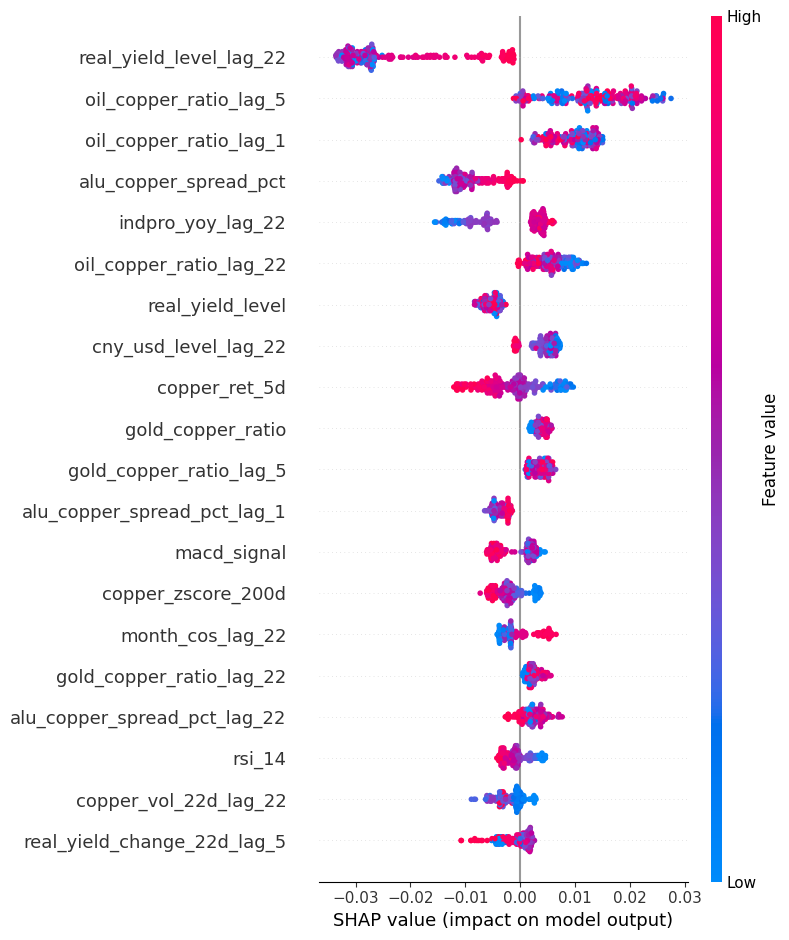

SHAP beeswarm saved.


In [ ]:
try:
    import shap
    shap.initjs()

    # Refit XGBoost on pruned features for SHAP
    xgb_shap = XGBoostModel()
    xgb_shap.fit(X_dev_pruned, y_dev)
    explainer = shap.TreeExplainer(xgb_shap._model)
    shap_values = explainer.shap_values(X_hold_pruned)

    fig_shap = plot_shap_summary(shap_values, list(X_hold_pruned.columns), top_n=20)
    fig_shap.show()

    # SHAP beeswarm (requires matplotlib)
    try:
        import matplotlib.pyplot as plt
        shap.summary_plot(shap_values, X_hold_pruned, max_display=20, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(CFG['output_dir'], 'shap_beeswarm.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('SHAP beeswarm saved.')
    except Exception as e:
        print(f'Beeswarm plot skipped: {e}')
except Exception as e:
    print(f'SHAP analysis skipped: {e}')

In [ ]:
# Top 10 features by mean |SHAP|
try:
    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X_hold_pruned.columns
    ).sort_values(ascending=False)
    print('Top 10 features by mean |SHAP|:')
    print(mean_abs_shap.head(10).to_string())
except NameError:
    print('SHAP values not available.')

Top 10 features by mean |SHAP|:
real_yield_level_lag_22    0.023034
oil_copper_ratio_lag_5     0.012902
oil_copper_ratio_lag_1     0.009602
alu_copper_spread_pct      0.008637
indpro_yoy_lag_22          0.005874
oil_copper_ratio_lag_22    0.005681
real_yield_level           0.005192
cny_usd_level_lag_22       0.004644
copper_ret_5d              0.004531
gold_copper_ratio          0.003871


## 12. Interactive Plotly Visualisations

In [ ]:
# Full dashboard: price history + best-model CV results
best_cv_df = cv_results[best_name]
fig_dashboard = plot_dashboard(df_aug, best_cv_df, model_name=best_name)
fig_dashboard.show()

In [ ]:
# Rolling Sharpe-equivalent for the best OOS model signal
best_oos_name = oos_summary['rmse'].idxmin()
oos_best = oos_results[best_oos_name]
signal_ret_oos = np.sign(oos_best['y_pred']) * oos_best['y_true']
rolling_sharpe = (signal_ret_oos.rolling(60).mean() /
                  signal_ret_oos.rolling(60).std().replace(0, np.nan)) * np.sqrt(252 / CFG['forecast_horizon'])

import plotly.graph_objects as go
fig_sharpe = go.Figure(go.Scatter(
    x=rolling_sharpe.index, y=rolling_sharpe,
    name='Rolling Sharpe (60-day)',
    line=dict(color='#b87333'),
))
fig_sharpe.add_hline(y=0, line_width=1, line_dash='dash', line_color='grey')
fig_sharpe.update_layout(
    title=f'Rolling 60-Day Signal Sharpe — {best_oos_name}',
    template='plotly_white',
    yaxis_title='Annualised Sharpe ratio',
)
fig_sharpe.show()

## 13. Scenario Analysis

The `ScenarioEngine` takes the trained ensemble model and the most recent feature vector,
then applies additive shocks to simulate what-if conditions.

### Built-in scenarios
| Scenario | Description |
|---|---|
| `bull_strong` | DXY −5%, real yields −50 bps, IP +3 pp |
| `bear_strong` | DXY +5%, real yields +50 bps, IP −3 pp |
| `china_demand_surge` | IP +5 pp, CNY appreciation |
| `supply_disruption` | Higher vol, short-term squeeze |
| `comex_inventory_drop_40pct` | Price above 200-day average, higher vol |
| `high_inflation` | Inflation breakeven +100 bps, lower real yields |
| `us_tariff_shock` | DXY +3%, equity drawdown, higher vol |

In [ ]:
# Use the latest feature vector (pruned)
latest_features = X_pruned_full.tail(1)
current_copper = float(df_aug['copper_price'].iloc[-1])

# Use the best-performing ensemble for scenarios
scenario_model = EnsembleModel([XGBoostModel(), LGBMModel()])
scenario_model.fit(X_dev_pruned, y_dev)

engine = ScenarioEngine(
    model=scenario_model,
    feature_template=latest_features,
    copper_price_current=current_copper,
    horizon=CFG['forecast_horizon'],
)
print(f'Current copper price: ${current_copper:,.0f}/t')
print(f'Baseline {CFG["forecast_horizon"]}-day forecast: ${engine.base_price:,.0f}/t')

Current copper price: $12,264/t
Baseline 22-day forecast: $12,943/t


In [ ]:
# Run all pre-defined scenarios
scenario_report = engine.report()
print('\n── Scenario Report ──')
print(scenario_report.to_string())


INFO | Scenario 'bull_strong': base=12943  forecast=12924  delta=-19 (-0.1%)
INFO | Scenario 'bear_strong': base=12943  forecast=12924  delta=-19 (-0.1%)
INFO | Scenario 'china_demand_surge': base=12943  forecast=12922  delta=-21 (-0.2%)
INFO | Scenario 'supply_disruption': base=12943  forecast=12896  delta=-46 (-0.4%)
INFO | Scenario 'comex_inventory_drop_40pct': base=12943  forecast=12828  delta=-115 (-0.9%)
INFO | Scenario 'high_inflation': base=12943  forecast=12953  delta=+10 (0.1%)
INFO | Scenario 'us_tariff_shock': base=12943  forecast=12939  delta=-3 (-0.0%)



── Scenario Report ──
                            base_price  scenario_price   delta  delta_pct
scenario                                                                 
comex_inventory_drop_40pct    12942.92        12827.76 -115.15      -0.89
supply_disruption             12942.92        12896.45  -46.46      -0.36
china_demand_surge            12942.92        12922.27  -20.65      -0.16
bear_strong                   12942.92        12923.68  -19.24      -0.15
bull_strong                   12942.92        12923.80  -19.11      -0.15
us_tariff_shock               12942.92        12939.43   -3.49      -0.03
high_inflation                12942.92        12952.59    9.68       0.07


In [ ]:
# Tornado chart
fig_tornado = plot_scenario_tornado(
    base_forecast=engine.base_price,
    scenario_results={row.Index: row.scenario_price for row in scenario_report.itertuples()},
)
fig_tornado.show()


In [ ]:
# Sensitivity sweep: DXY shock (1-day return)
dxy_shocks = np.linspace(-0.02, 0.02, 21)  # tighter range for 1-day
sweep_dxy = engine.sweep('dxy_ret_1d', dxy_shocks.tolist(), label='DXY 1d return shock')

fig_sweep = go.Figure(go.Scatter(
    x=sweep_dxy['shock'], y=sweep_dxy['forecast_price'],
    mode='lines+markers', line=dict(color='#b87333'),
    name='Forecast price',
))
fig_sweep.add_hline(y=engine.base_price, line_dash='dash', line_color='grey',
                    annotation_text='Baseline')
fig_sweep.update_layout(
    title='Copper Price Sensitivity to DXY 1-Day Return Shock',
    xaxis_title='DXY 1d return shock (additive)',
    yaxis_title='Forecast Copper Price ($/t)',
    template='plotly_white',
)
fig_sweep.show()


In [ ]:
# Custom scenario: combined geopolitical / tariff shock (1-day magnitudes)
custom_scenario = {
    'dxy_ret_1d':           0.01,   # DXY up 1% in a day
    'sp500_ret_1d':        -0.02,   # equities down 2%
    'copper_vol_5d':        0.05,   # vol spike
    'real_yield_change_1d': 0.05,   # yields up 5 bps
}
result = engine.run('geo_tariff_shock', shocks=custom_scenario)
print('Custom scenario result:')
for k, v in result.items():
    print(f'  {k}: {v}')


INFO | Scenario 'geo_tariff_shock': base=12943  forecast=12912  delta=-31 (-0.2%)


Custom scenario result:
  scenario: geo_tariff_shock
  base_price: 12942.92
  scenario_price: 12911.7
  delta: -31.21
  delta_pct: -0.24


## 15. Best Model Selection & Next-Day Forecast

Select the best model from the OOS backtest (by Signal Sharpe ratio), refit it on all
available data, and produce tomorrow's price forecast with an 80% confidence interval.


In [ ]:
# 1. Select best model from OOS backtest (highest Signal Sharpe)
best_name_sharpe = oos_summary['signal_sharpe'].idxmax()
best_name_rmse   = oos_summary['rmse'].idxmin()
print(f'Best by Signal Sharpe : {best_name_sharpe}')
print(f'Best by RMSE          : {best_name_rmse}')
print(f'Using: {best_name_sharpe} (Sharpe-optimised for trading)')

# Map name -> freshly instantiated model
_model_zoo = {
    'NaiveModel':    NaiveModel(),
    'LinearModel':   LinearModel(),
    'XGBoostModel':  XGBoostModel(),
    'LGBMModel':     LGBMModel(),
    'ARIMAXModel':   ARIMAXModel(exog_cols=['dxy_level','real_yield_level','gold_copper_ratio','copper_vol_5d']),
    'HybridModel':   HybridModel(backbone=ARIMAXModel(exog_cols=['dxy_level','real_yield_level','gold_copper_ratio','copper_vol_5d'])),
    'EnsembleModel': EnsembleModel([XGBoostModel(), LGBMModel()]),
}
if HAS_PROPHET:
    _model_zoo['ProphetModel'] = ProphetModel(regressor_cols=['dxy_level','real_yield_level','gold_copper_ratio','copper_vol_5d'])

best_model = _model_zoo.get(best_name_sharpe, LGBMModel())

# 2. Refit on ALL available pruned data (development + holdout)
best_model.fit(X_pruned_full, y_ret.reindex(X_pruned_full.index))
print(f'\nRefitted {best_name_sharpe} on {len(X_pruned_full)} rows '
      f'({X_pruned_full.index.min().date()} -> {X_pruned_full.index.max().date()})')

# 3. Forecast the next trading day
X_today   = X_pruned_full.iloc[[-1]]   # most recent available feature row
today_dt  = X_pruned_full.index[-1]
tomorrow  = today_dt + pd.offsets.BDay(1)

pred_return = float(best_model.predict(X_today)[0])
last_price  = float(df_aug['copper_price'].iloc[-1])
pred_price  = last_price * np.exp(pred_return)

# 4. 80% Confidence interval
if hasattr(best_model, 'predict_interval'):
    try:
        ci = best_model.predict_interval(X_today, alpha=CFG['ci_alpha'])
        ci_lo = last_price * np.exp(float(ci['lower'].iloc[0]))
        ci_hi = last_price * np.exp(float(ci['upper'].iloc[0]))
        ci_str = f'${ci_lo:,.0f} - ${ci_hi:,.0f}'
    except Exception:
        ci_lo, ci_hi = None, None
        ci_str = 'N/A (fallback below)'
else:
    ci_lo, ci_hi = None, None
    ci_str = 'N/A'

# Fallback: QuantileForecaster CI if model doesn't provide intervals
if ci_lo is None:
    q_fc = QuantileForecaster(alpha=CFG['ci_alpha'])
    q_fc.fit(X_pruned_full, y_ret.reindex(X_pruned_full.index))
    ci_q  = q_fc.predict_interval(X_today)
    ci_lo = last_price * np.exp(float(ci_q['lower'].iloc[0]))
    ci_hi = last_price * np.exp(float(ci_q['upper'].iloc[0]))
    ci_str = f'${ci_lo:,.0f} - ${ci_hi:,.0f} (QuantileForecaster)'

# 5. Print result
direction = 'Bullish (+)' if pred_return > 0 else 'Bearish (-)'
print('\n' + '='*60)
print(f'  COPPER 1-DAY FORECAST  ({best_name_sharpe})')
print('='*60)
print(f'  Data as of   : {today_dt.date()}')
print(f'  Forecast date: {tomorrow.date()}')
print(f'  Current price: ${last_price:,.0f}/t')
print(f'  Pred. return : {pred_return:+.4f}  ({pred_return*100:+.2f}%)')
print(f'  Pred. price  : ${pred_price:,.0f}/t')
print(f'  80% CI       : {ci_str}')
print(f'  Signal       : {direction}')
print('='*60)


## 14. Export Results

All outputs are saved to `./outputs/` as CSV and JSON for downstream use
(e.g. Power BI, Tableau, or automated reporting pipelines).

In [ ]:
import json
from datetime import date

out_dir = CFG['output_dir']

# 1. Forecast with CI
forecast_df.reset_index().rename(columns={'index': 'date'}).to_csv(
    os.path.join(out_dir, 'forecast_ci.csv'), index=False
)

# 2. OOS backtest results
for name, df_oos in oos_results.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    df_oos.to_csv(os.path.join(out_dir, f'oos_{safe_name}.csv'))

# 3. Model comparison summary
oos_summary.to_csv(os.path.join(out_dir, 'model_comparison.csv'))

# 4. Scenario report
scenario_report.to_csv(os.path.join(out_dir, 'scenario_report.csv'))

# 5. Cointegration results
coint_df.to_csv(os.path.join(out_dir, 'cointegration_results.csv'))

# 6. JSON summary (for APIs / dashboards)
summary_json = {
    'generated_at':      date.today().isoformat(),
    'current_price':     round(current_copper, 2),
    'baseline_forecast': round(engine.base_price, 2),
    'horizon_days':      CFG['forecast_horizon'],
    'best_model':        best_oos_name,
    'oos_metrics':       oos_metrics[best_oos_name],
    'scenarios':         scenario_report.reset_index().to_dict(orient='records'),
}
with open(os.path.join(out_dir, 'forecast_summary.json'), 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f'All outputs saved to {out_dir}/')
print('Files:', os.listdir(out_dir))

All outputs saved to ./outputs/
Files: ['cointegration_results.csv', 'forecast_ci.csv', 'forecast_summary.json', 'model_comparison.csv', 'oos_ARIMAX.csv', 'oos_EnsembleXGBoost+LightGBM.csv', 'oos_HybridARIMAX+LightGBM.csv', 'oos_LightGBM.csv', 'oos_Linear_Ridge.csv', 'oos_Naive_RW.csv', 'oos_Prophet.csv', 'oos_XGBoost.csv', 'scenario_report.csv', 'shap_beeswarm.png']


---
## Summary

| Step | Completed |
|---|---|
| Data ingestion (yfinance + FRED + COT) | ✅ |
| Cointegration analysis (Engle-Granger + ECT features) | ✅ |
| Regime detection (3-state HMM) | ✅ |
| Feature engineering (price, cross-asset, macro, calendar, COT, structural) | ✅ |
| Model training: Naive, Ridge, XGBoost, LightGBM, ARIMAX, Prophet, Hybrid, Ensembles | ✅ |
| Feature pruning (SHAP-based bottom 20% removal) | ✅ |
| Optuna hyper-parameter tuning | ✅ |
| Walk-forward cross-validation (with signal Sharpe) | ✅ |
| Out-of-sample backtest (last 12 months) | ✅ |
| Forecast with 80% CI (quantile + ARIMAX intervals) | ✅ |
| SHAP explainability | ✅ |
| Interactive Plotly visualisations | ✅ |
| Scenario analysis | ✅ |
| JSON / CSV export | ✅ |